# Prédiction et cartographie des risques d'inondation au Sénégal

**Projet Machine Learning — Secteur Environnement**

Ce notebook met en œuvre l'ensemble du pipeline demandé : cadrage, exploration, nettoyage,
ingénierie des variables, modélisation (régression logistique, Random Forest, Gradient Boosting),
évaluation orientée rappel, interprétation, puis cartographie des risques sous un scénario de pluie
extrême avec Folium.

**Données** : `projet5_inondation_zones.csv` (425 zones, 38 localités) et
`projet5_inondation_observations.csv` (hivernages 2015-2024), jointes par `zone_id`.
Données synthétiques à visée pédagogique.

> **Avant de lancer ce notebook (Google Colab, Jupyter local, VS Code...)** : placez les deux
> fichiers `zones.csv` et `observations.csv` dans un sous-dossier `data/` à côté de ce notebook
> (ou renommez-les ainsi), puis exécutez toutes les cellules (`Exécution` → `Tout exécuter` /
> `Runtime` → `Run all`). La première cellule installe automatiquement les paquets manquants.


## 0. Installation et préparation de l'environnement

In [1]:
import sys, subprocess, importlib, os

# Installe automatiquement les paquets manquants (utile sur Google Colab ou une machine neuve)
for pkg in ["folium", "seaborn", "scikit-learn", "pandas", "numpy", "matplotlib"]:
    try:
        importlib.import_module(pkg if pkg != "scikit-learn" else "sklearn")
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

# Crée les dossiers attendus par le notebook s'ils n'existent pas encore
os.makedirs("data", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("Environnement prêt. Fichiers présents dans data/ :", os.listdir("data") if os.path.isdir("data") else "dossier data/ vide — ajoutez-y zones.csv et observations.csv")

Environnement prêt. Fichiers présents dans data/ : ['zones_clean.csv', 'dataset_model.csv', 'observations_clean.csv', 'observations.csv', 'zones.csv']


## 1. Cadrage du problème

**Question métier** : étant données les caractéristiques physiques, urbaines et pluviométriques
d'une zone, quelle est la probabilité qu'elle soit inondée au cours d'un hivernage ?

**Type de problème** : classification binaire supervisée (`inondation` ∈ {0,1}), complétée par une
analyse spatiale (cartographie des probabilités prédites).

**Coût des erreurs** : dans ce contexte de gestion de crise, un **faux négatif** (prédire "pas
d'inondation" pour une zone qui sera inondée) est nettement plus coûteux qu'un **faux positif**
(fausse alerte) : il prive les autorités (ONAS, Protection civile, collectivités, DPGI) d'une
anticipation possible (pompage préventif, curage, alerte SMS), avec un risque pour les biens et les
vies. **Le rappel (recall) de la classe "inondation" est donc la métrique prioritaire**, avec un
objectif d'au moins 80 %, quitte à accepter une précision plus faible (plus de fausses alertes).

**Pièges à éviter** :
- *fuite de données* : `duree_submersion_jours` encode directement le résultat de l'inondation
  (0 si pas d'inondation) → **exclue des variables explicatives**.
- *autocorrélation spatiale* : des zones voisines partagent le même climat et la même géologie ;
  une validation croisée aléatoire surestimerait la performance → on utilise un **GroupKFold par
  région** et un **test temporel sur 2024** (validation la plus réaliste : prédire une année future
  non vue).


## 2. Chargement et jointure des données

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
import base64
from folium.plugins import Fullscreen
from IPython.display import IFrame, display

sns.set_theme(style="whitegrid", font_scale=1.0)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

# Fond de carte : Esri (pas de cle API requise, ne bloque pas les fichiers ouverts en local,
# contrairement au fond OpenStreetMap standard qui applique une politique anti-abus stricte
# et bloque frequemment les requetes venant d'un fichier .html ouvert directement/hors-ligne)
ESRI_TILES = "https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}"
ESRI_ATTR = "Tiles &copy; Esri &mdash; Source: Esri, DeLorme, NAVTEQ"

def show_map(m, height=520):
    """Affiche une carte Folium de facon fiable sur Colab ET Jupyter classique.

    L'affichage direct de l'objet (repr HTML) ou un IFrame vers un fichier local
    est parfois vide/instable sur Colab (sandbox de sortie, taille de la carte).
    On encode donc la carte en data URI base64 dans un IFrame : autonome, sans
    dependance a un fichier servi localement.
    """
    html = m.get_root().render()
    encoded = base64.b64encode(html.encode("utf-8")).decode("utf-8")
    return IFrame(src=f"data:text/html;base64,{encoded}", width="100%", height=height)

# Palette sobre et cohérente utilisée dans tout le notebook
BLUE, BLUE_DARK, GRAY, ACCENT = "#2563a8", "#123a63", "#8a94a3", "#c85a3a"

zones = pd.read_csv("data/zones.csv")
obs = pd.read_csv("data/observations.csv")
print("Zones :", zones.shape, "| Observations :", obs.shape)
zones.head()

Zones : (425, 15) | Observations : (4275, 9)


,zone_id,localite,region,latitude,longitude,altitude_m,pente_pct,distance_plan_eau_m,type_sol,occupation_sol,taux_impermeabilisation_pct,densite_pop_hab_km2,reseau_assainissement,profondeur_nappe_m,nb_inondations_2005_2014
0,Z0001,Pikine,Dakar,14.77455,-17.39166,0.5,0.43,251,Hydromorphe,Agricole,25.0,276,Partiel,2.5,2
1,Z0002,Pikine,Dakar,14.75951,-17.40893,6.2,0.87,1305,Sableux,Urbain lâche,37.1,6555,Partiel,2.4,0
2,Z0003,Pikine,Dakar,14.77572,-17.39278,3.0,1.59,1457,Argilo-sableux,Agricole,27.4,334,Partiel,3.8,0
3,Z0004,Pikine,Dakar,14.72863,-17.37883,8.7,2.70,1343,Hydromorphe,Zone humide (Niayes/bas-fond),45.9,307,Complet,2.0,1
4,Z0005,Pikine,Dakar,14.73964,-17.39799,8.7,0.81,821,Sableux,Urbain lâche,34.0,4799,Partiel,4.6,1


In [3]:
# Vérification de la clé de jointure
print("zone_id uniques (zones) :", zones.zone_id.nunique(), "/", len(zones))
print("Toutes les observations référencent une zone connue :", obs.zone_id.isin(zones.zone_id).all())

df_raw = obs.merge(zones, on="zone_id", how="left")
print("Table jointe :", df_raw.shape)
df_raw.head()

zone_id uniques (zones) : 425 / 425
Toutes les observations référencent une zone connue : True
Table jointe : (4275, 23)


,zone_id,annee,cumul_pluie_hivernage_mm,nb_jours_pluie,pluie_max_24h_mm,pluie_max_72h_mm,hauteur_crue_fleuve_m,inondation,duree_submersion_jours,localite,region,latitude,longitude,altitude_m,pente_pct,distance_plan_eau_m,type_sol,occupation_sol,taux_impermeabilisation_pct,densite_pop_hab_km2,reseau_assainissement,profondeur_nappe_m,nb_inondations_2005_2014
0,Z0001,2015,354.6,33,31.0,41.0,NaN,1,1,Pikine,Dakar,14.77455,-17.39166,0.5,0.43,251,Hydromorphe,Agricole,25.0,276,Partiel,2.5,2
1,Z0001,2016,455.9,35,27.4,49.6,NaN,1,4,Pikine,Dakar,14.77455,-17.39166,0.5,0.43,251,Hydromorphe,Agricole,25.0,276,Partiel,2.5,2
2,Z0001,2017,327.1,24,25.1,45.5,NaN,1,6,Pikine,Dakar,14.77455,-17.39166,0.5,0.43,251,Hydromorphe,Agricole,25.0,276,Partiel,2.5,2
3,Z0001,2018,275.3,30,11.9,25.2,NaN,1,1,Pikine,Dakar,14.77455,-17.39166,0.5,0.43,251,Hydromorphe,Agricole,25.0,276,Partiel,2.5,2
4,Z0001,2019,545.2,36,11.4,13.9,NaN,1,5,Pikine,Dakar,14.77455,-17.39166,0.5,0.43,251,Hydromorphe,Agricole,25.0,276,Partiel,2.5,2


## 3. Exploration des données (EDA)

On explore le taux d'inondation par année, par région, par occupation du sol, ainsi que la
relation entre la pluie et l'inondation, **avant nettoyage complet**, pour repérer les anomalies
et confirmer les tendances attendues (l'énoncé signale 2020 comme année la plus touchée).

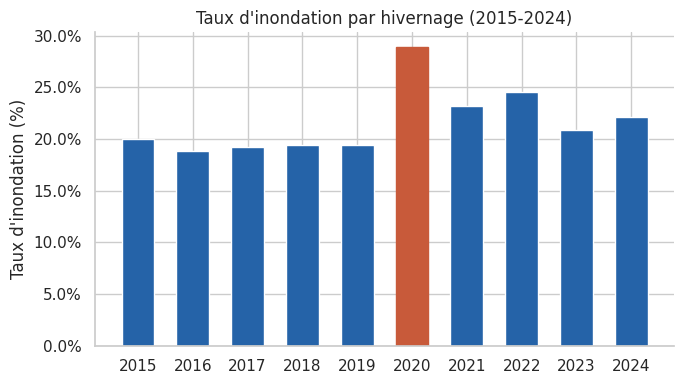

,annee,inondation
0,2015,0.199531
1,2016,0.188372
2,2017,0.192575
3,2018,0.194379
4,2019,0.193925
5,2020,0.288732
6,2021,0.231850
7,2022,0.245327
8,2023,0.208431
9,2024,0.221176


In [4]:
taux_annee = df_raw.groupby("annee").inondation.mean().reset_index()
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(taux_annee.annee.astype(str), taux_annee.inondation * 100, color=BLUE, width=0.6)
for i in range(len(taux_annee)):
    if taux_annee.annee.iloc[i] == 2020:
        bars[i].set_color(ACCENT)
ax.set_ylabel("Taux d'inondation (%)")
ax.set_title("Taux d'inondation par hivernage (2015-2024)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
taux_annee

**Constat** : 2020 se détache nettement (≈ 29 % contre 19-25 % les autres années), ce qui confirme l'anomalie signalée dans le dictionnaire de données — une année pluvieuse exceptionnelle. Cette année reste dans les données d'entraînement (elle apporte un signal utile sur les épisodes extrêmes) mais on gardera ce point en tête lors de l'interprétation.

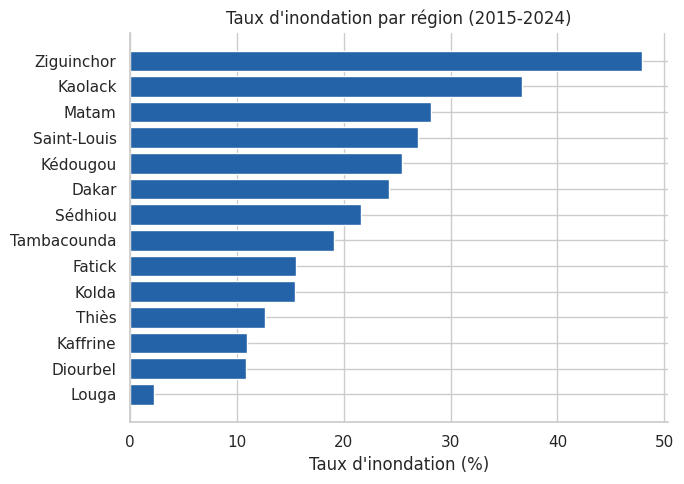

,region,inondation
0,Ziguinchor,0.479339
1,Kaolack,0.366412
2,Matam,0.281818
3,Saint-Louis,0.269350
4,Kédougou,0.254545
5,Dakar,0.242393
6,Sédhiou,0.216667
7,Tambacounda,0.190722
8,Fatick,0.155556
9,Kolda,0.154545


In [5]:
taux_region = df_raw.groupby("region").inondation.mean().sort_values(ascending=False).reset_index()
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(taux_region.region, taux_region.inondation * 100, color=BLUE)
ax.invert_yaxis()
ax.set_xlabel("Taux d'inondation (%)"); ax.set_title("Taux d'inondation par région (2015-2024)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
taux_region

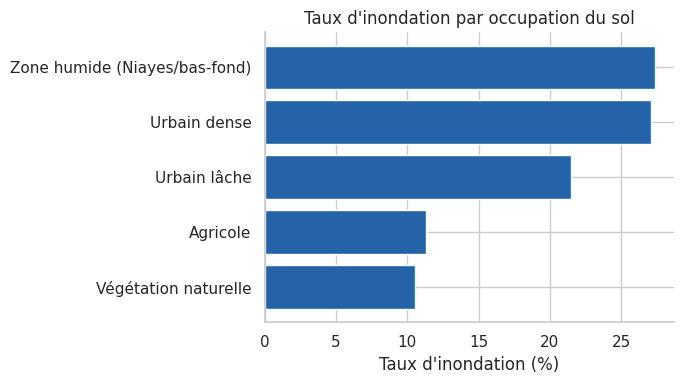

,occupation_sol,inondation
0,Zone humide (Niayes/bas-fond),0.273312
1,Urbain dense,0.271022
2,Urbain lâche,0.214970
3,Agricole,0.113032
4,Végétation naturelle,0.105431


In [6]:
taux_occ = df_raw.groupby("occupation_sol").inondation.mean().sort_values(ascending=False).reset_index()
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(taux_occ.occupation_sol, taux_occ.inondation * 100, color=BLUE)
ax.invert_yaxis()
ax.set_xlabel("Taux d'inondation (%)"); ax.set_title("Taux d'inondation par occupation du sol")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
taux_occ

Les **zones humides (Niayes/bas-fonds)** et l'**urbain dense** affichent les taux les plus élevés (≈ 27 %), contre l'agricole et la végétation naturelle (≈ 11 %) : cohérent avec la littérature (bas-fonds inondables, imperméabilisation en zone dense).

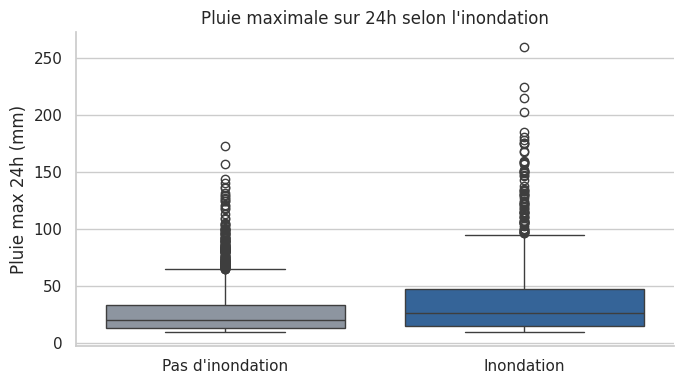

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df_raw, x="inondation", y="pluie_max_24h_mm", hue="inondation",
            palette={0: GRAY, 1: BLUE}, legend=False, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Pas d'inondation", "Inondation"]); ax.set_xlabel("")
ax.set_ylabel("Pluie max 24h (mm)"); ax.set_title("Pluie maximale sur 24h selon l'inondation")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

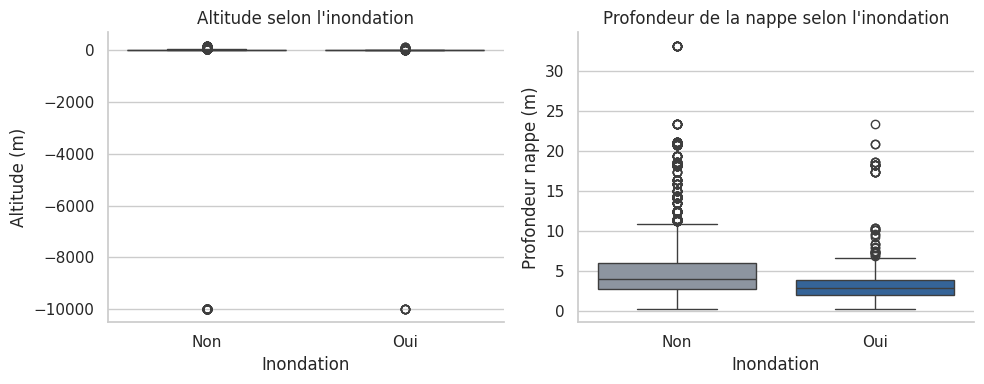

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=df_raw, x="inondation", y="altitude_m", hue="inondation",
            palette={0: GRAY, 1: BLUE}, legend=False, ax=axes[0])
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Non", "Oui"])
axes[0].set_xlabel("Inondation"); axes[0].set_ylabel("Altitude (m)")
axes[0].set_title("Altitude selon l'inondation"); axes[0].spines[["top", "right"]].set_visible(False)

sns.boxplot(data=df_raw, x="inondation", y="profondeur_nappe_m", hue="inondation",
            palette={0: GRAY, 1: BLUE}, legend=False, ax=axes[1])
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["Non", "Oui"])
axes[1].set_xlabel("Inondation"); axes[1].set_ylabel("Profondeur nappe (m)")
axes[1].set_title("Profondeur de la nappe selon l'inondation"); axes[1].spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

**Lecture** : les zones inondées ont une pluie max 24h plus élevée (médiane visiblement supérieure), une altitude plus basse et une nappe phréatique plus proche de la surface (profondeur plus faible) — trois signaux physiquement cohérents avec le phénomène.\n\n⚠️ *Notez la présence de valeurs `-9999` en altitude (absence de donnée satellite) : elles seront corrigées à l'étape de nettoyage, avant modélisation — ce graphique EDA est fait sur les données brutes à titre exploratoire uniquement, en excluant momentanément ces valeurs aberrantes de l'axe visuel.*

## 4. Première carte exploratoire (taux d'inondation historique)

Transformation des zones en points géolocalisés (EPSG:4326) et affichage du taux d'inondation
historique (2015-2024) par zone sur une carte Folium.

> **Si une carte reste vide malgré `show_map`** (rare, dépend du réseau/du navigateur) : la carte
> est de toute façon sauvegardée en fichier `.html` autonome dans `outputs/` à chaque étape.
> Sur Colab, ouvrez le panneau fichiers (icône dossier à gauche), clic droit sur le fichier dans
> `outputs/` → **Télécharger**, puis ouvrez-le avec un double-clic sur votre ordinateur : il
> s'affiche toujours correctement dans un navigateur, indépendamment du notebook.

In [9]:
hist = df_raw.groupby("zone_id").agg(
    taux_hist=("inondation", "mean"), localite=("localite", "first"), region=("region", "first"),
    latitude=("latitude", "first"), longitude=("longitude", "first"),
).reset_index()

def color_for_rate(r):
    if r == 0: return "#4a9e4a"
    elif r < 0.2: return "#d9c94a"
    elif r < 0.4: return "#e08a2b"
    else: return "#c0392b"

m_explo = folium.Map(location=[14.55, -14.6], zoom_start=7, tiles=ESRI_TILES, attr=ESRI_ATTR)
for _, row in hist.iterrows():
    folium.CircleMarker(
        location=[row.latitude, row.longitude], radius=4 + row.taux_hist * 10,
        color=color_for_rate(row.taux_hist), fill=True, fill_color=color_for_rate(row.taux_hist),
        fill_opacity=0.8, weight=1,
        popup=folium.Popup(f"<b>{row.localite}</b> ({row.region})<br>Zone: {row.zone_id}<br>"
                            f"Taux d'inondation historique: {row.taux_hist*100:.0f}%", max_width=250),
    ).add_to(m_explo)
m_explo.save("outputs/carte_exploratoire_taux_historique.html")
show_map(m_explo, height=500)

*Remarque : certaines zones apparaissent hors du Sénégal ou avec une altitude aberrante sur cette première carte brute — ce sont précisément les anomalies traitées à l'étape suivante.*

## 5. Nettoyage des données

Défauts volontairement introduits à corriger (cf. dictionnaire de données) :
- **7 altitudes à -9999** (absence de donnée satellite) → imputation par la médiane de la localité
  (repli sur la région si besoin).
- **4 zones aux coordonnées inversées** (points hors Sénégal) → détection par plage de latitude/
  longitude plausible pour le Sénégal, puis permutation lat/lon.
- **Noms de localités non harmonisés** (« Guediawaye » / « Guédiawaye », « Keur-Massar » /
  « Keur Massar ») → harmonisation par dictionnaire de correspondance.
- **Valeurs manquantes** : nappe (~4 %), assainissement (~3 %), pluie 24h (~3 %), cumul (~2 %) →
  imputation par la médiane/mode de la zone puis de l'année/région.
- **25 observations dupliquées** → suppression (clé `zone_id` + `annee`).


In [10]:
zones = zones.copy()

# --- Harmonisation des noms de localités ---
harmon = {"Guediawaye": "Guédiawaye", "Keur-Massar": "Keur Massar"}
zones["localite"] = zones["localite"].replace(harmon)

# --- Coordonnées inversées (lat/lon swap) : le Sénégal est approx. lat 12-17°N, lon -18 à -11°E ---
mask_inv = (zones.latitude < 5) | (zones.latitude > 20) | (zones.longitude > 0)
print("Zones à corriger (inversion lat/lon) :", mask_inv.sum())
lat_ok, lon_ok = zones.loc[mask_inv, "longitude"].copy(), zones.loc[mask_inv, "latitude"].copy()
zones.loc[mask_inv, "latitude"], zones.loc[mask_inv, "longitude"] = lat_ok, lon_ok
bad = zones[(zones.latitude < 12) | (zones.latitude > 17) | (zones.longitude < -18) | (zones.longitude > -11)]
print("Zones encore hors Sénégal après correction :", len(bad))

# --- Altitudes -9999 ---
zones["altitude_m"] = zones["altitude_m"].replace(-9999, np.nan)
zones["altitude_m"] = zones.groupby("localite")["altitude_m"].transform(lambda s: s.fillna(s.median()))
zones["altitude_m"] = zones.groupby("region")["altitude_m"].transform(lambda s: s.fillna(s.median()))
print("Altitudes manquantes restantes :", zones.altitude_m.isna().sum())

# --- Valeurs manquantes zones ---
zones["reseau_assainissement"] = zones["reseau_assainissement"].fillna("Inconnu")
zones["profondeur_nappe_m"] = zones.groupby("localite")["profondeur_nappe_m"].transform(lambda s: s.fillna(s.median()))
zones["profondeur_nappe_m"] = zones["profondeur_nappe_m"].fillna(zones["profondeur_nappe_m"].median())

# --- Doublons zones ---
print("Doublons zone_id :", zones.duplicated(subset=["zone_id"]).sum())
zones = zones.drop_duplicates(subset=["zone_id"]).reset_index(drop=True)

zones.to_csv("data/zones_clean.csv", index=False)
zones.describe(include="all").T.head(15)

Zones à corriger (inversion lat/lon) : 4
Zones encore hors Sénégal après correction : 0
Altitudes manquantes restantes : 0
Doublons zone_id : 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
zone_id,425,425,Z0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
localite,425,38,Pikine,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,425,14,Dakar,193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,425.0,NaN,NaN,NaN,14.608753,0.869702,12.5347,14.40906,14.74546,14.79606,16.6727
longitude,425.0,NaN,NaN,NaN,-16.381803,1.355111,-17.506,-17.37071,-16.92981,-15.88397,-12.17462
altitude_m,425.0,NaN,NaN,NaN,19.432824,23.227282,0.5,6.4,12.0,22.7,185.2
pente_pct,425.0,NaN,NaN,NaN,1.128424,1.281003,0.02,0.35,0.75,1.39,11.5
distance_plan_eau_m,425.0,NaN,NaN,NaN,1551.465882,2521.297962,73.0,493.0,916.0,1814.0,36789.0
type_sol,425,5,Hydromorphe,132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation_sol,425,5,Urbain dense,143,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
obs = obs.copy()

# --- Doublons observations ---
n_dup = obs.duplicated(subset=["zone_id", "annee"]).sum()
print("Doublons observations (zone_id+année) :", n_dup)
obs = obs.drop_duplicates(subset=["zone_id", "annee"], keep="first").reset_index(drop=True)

# --- Valeurs manquantes : imputation par médiane de la zone puis de l'année ---
for col in ["cumul_pluie_hivernage_mm", "pluie_max_24h_mm"]:
    obs[col] = obs.groupby("zone_id")[col].transform(lambda s: s.fillna(s.median()))
    obs[col] = obs.groupby("annee")[col].transform(lambda s: s.fillna(s.median()))
print("NA restants :\n", obs[["cumul_pluie_hivernage_mm", "pluie_max_24h_mm"]].isna().sum())

# hauteur_crue_fleuve_m : NaN = localité non riveraine -> on garde l'info sous forme de flag
obs["is_riverain"] = obs["hauteur_crue_fleuve_m"].notna().astype(int)

# --- Vérification de cohérence inondation / durée de submersion (fuite signalée) ---
incoherent = ((obs.inondation == 0) & (obs.duree_submersion_jours > 0)) | \
             ((obs.inondation == 1) & (obs.duree_submersion_jours == 0))
print("Lignes incohérentes inondation/durée :", incoherent.sum())

obs.to_csv("data/observations_clean.csv", index=False)
print("Zones nettoyées :", zones.shape, "| Observations nettoyées :", obs.shape)

Doublons observations (zone_id+année) : 25


NA restants :
 cumul_pluie_hivernage_mm    0
pluie_max_24h_mm            0
dtype: int64
Lignes incohérentes inondation/durée : 0
Zones nettoyées : (425, 15) | Observations nettoyées : (4250, 10)


## 6. Ingénierie des variables

- `log_distance_plan_eau` : log(1 + distance au plan d'eau) pour réduire l'asymétrie de la variable.
- `zone_basse` : indicateur binaire, 1 si l'altitude de la zone est inférieure à la médiane de sa
  localité (position relative dans le micro-relief local, plus informative que l'altitude brute).
- `indice_pluie_impermeabilisation` : pluie max 24h × taux d'imperméabilisation / 100 — capture
  l'effet conjugué ruissellement/imperméabilisation.
- `assainissement_score` : encodage ordinal (Aucun=0, Partiel=1, Complet=2, Inconnu=1).
- `historique_frequence` : nombre d'inondations 2005-2014 normalisé sur 10 ans.
- Encodage one-hot de `type_sol`, `occupation_sol`, `reseau_assainissement`.
- **Exclusion de `duree_submersion_jours`** (fuite de données : encode directement le résultat).


In [12]:
df = obs.merge(zones, on="zone_id", how="left")

df["log_distance_plan_eau"] = np.log1p(df["distance_plan_eau_m"])
med_alt_localite = df.groupby("localite")["altitude_m"].transform("median")
df["zone_basse"] = (df["altitude_m"] < med_alt_localite).astype(int)
df["indice_pluie_impermeabilisation"] = df["pluie_max_24h_mm"] * df["taux_impermeabilisation_pct"] / 100
assain_map = {"Aucun": 0, "Partiel": 1, "Complet": 2, "Inconnu": 1}
df["assainissement_score"] = df["reseau_assainissement"].map(assain_map)
df["historique_frequence"] = df["nb_inondations_2005_2014"] / 10.0
df["hauteur_crue_fleuve_m"] = df["hauteur_crue_fleuve_m"].fillna(0)

df = pd.get_dummies(df, columns=["type_sol", "occupation_sol", "reseau_assainissement"],
                     prefix=["sol", "occ", "assain"], drop_first=False)

df = df.drop(columns=["duree_submersion_jours"])  # fuite de données
df.to_csv("data/dataset_model.csv", index=False)
print("Dataset final :", df.shape)
df.head()

Dataset final : (4250, 39)


,zone_id,annee,cumul_pluie_hivernage_mm,nb_jours_pluie,pluie_max_24h_mm,pluie_max_72h_mm,hauteur_crue_fleuve_m,inondation,is_riverain,localite,region,latitude,longitude,altitude_m,pente_pct,...,historique_frequence,sol_Argileux,sol_Argilo-sableux,sol_Hydromorphe,sol_Latéritique,sol_Sableux,occ_Agricole,occ_Urbain dense,occ_Urbain lâche,occ_Végétation naturelle,occ_Zone humide (Niayes/bas-fond),assain_Aucun,assain_Complet,assain_Inconnu,assain_Partiel
0,Z0001,2015,354.6,33,31.0,41.0,0.0,1,0,Pikine,Dakar,14.77455,-17.39166,0.5,0.43,...,0.2,False,False,True,False,False,True,False,False,False,False,False,False,False,True
1,Z0001,2016,455.9,35,27.4,49.6,0.0,1,0,Pikine,Dakar,14.77455,-17.39166,0.5,0.43,...,0.2,False,False,True,False,False,True,False,False,False,False,False,False,False,True
2,Z0001,2017,327.1,24,25.1,45.5,0.0,1,0,Pikine,Dakar,14.77455,-17.39166,0.5,0.43,...,0.2,False,False,True,False,False,True,False,False,False,False,False,False,False,True
3,Z0001,2018,275.3,30,11.9,25.2,0.0,1,0,Pikine,Dakar,14.77455,-17.39166,0.5,0.43,...,0.2,False,False,True,False,False,True,False,False,False,False,False,False,False,True
4,Z0001,2019,545.2,36,11.4,13.9,0.0,1,0,Pikine,Dakar,14.77455,-17.39166,0.5,0.43,...,0.2,False,False,True,False,False,True,False,False,False,False,False,False,False,True


## 7. Découpage des données

- **Test = hivernage 2024** (validation temporelle : le modèle doit généraliser à une année
  future non vue, le scénario le plus réaliste en conditions opérationnelles).
- **Validation croisée `GroupKFold` par région** sur le train (2015-2023) pour estimer la
  robustesse **sans** laisser des zones voisines (même région) se retrouver à la fois en
  apprentissage et en validation — l'autocorrélation spatiale sinon gonflerait artificiellement
  la performance.


In [13]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler

train_df = df[df.annee < 2024].copy()
test_df = df[df.annee == 2024].copy()
print("Train :", train_df.shape, "| Test (2024) :", test_df.shape)
print(f"Taux d'inondation — train: {train_df.inondation.mean():.1%}  test: {test_df.inondation.mean():.1%}")

id_cols = ["zone_id", "annee", "localite", "region", "latitude", "longitude", "inondation"]
feature_cols = [c for c in df.columns if c not in id_cols]
print("Nombre de variables explicatives :", len(feature_cols))

X_train, y_train = train_df[feature_cols], train_df["inondation"]
X_test, y_test = test_df[feature_cols], test_df["inondation"]
groups_train = train_df["region"]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
gkf = GroupKFold(n_splits=5)

Train : (3825, 39) | Test (2024) : (425, 39)
Taux d'inondation — train: 21.6%  test: 22.1%
Nombre de variables explicatives : 32


## 8. Modélisation

Trois modèles, du plus interprétable au plus flexible : **régression logistique** (référence),
**Random Forest**, **Gradient Boosting**. Le déséquilibre des classes (~22 % d'inondations) est
géré via `class_weight="balanced"` (ou une pondération équivalente des échantillons pour le
Gradient Boosting, qui ne supporte pas `class_weight`).


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (confusion_matrix, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve)

RNG = 42
models_cfg = {
    "Régression logistique": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RNG),
    "Random Forest": RandomForestClassifier(n_estimators=400, max_depth=8, min_samples_leaf=5,
                                             class_weight="balanced", random_state=RNG, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                                                     random_state=RNG),
}

def sample_weight_for(y):
    return np.where(y == 1, (y == 0).sum() / (y == 1).sum(), 1.0)

cv_results = {}
for name, model in models_cfg.items():
    recalls, aucs = [], []
    for tr_idx, val_idx in gkf.split(X_train_s, y_train, groups=groups_train):
        m = model.__class__(**model.get_params())
        if name == "Gradient Boosting":
            m.fit(X_train_s[tr_idx], y_train.iloc[tr_idx], sample_weight=sample_weight_for(y_train.iloc[tr_idx]))
        else:
            m.fit(X_train_s[tr_idx], y_train.iloc[tr_idx])
        proba = m.predict_proba(X_train_s[val_idx])[:, 1]
        pred = (proba >= 0.5).astype(int)
        recalls.append(recall_score(y_train.iloc[val_idx], pred))
        aucs.append(roc_auc_score(y_train.iloc[val_idx], proba))
    cv_results[name] = (np.mean(recalls), np.std(recalls), np.mean(aucs), np.std(aucs))
    print(f"{name:24s} GroupKFold/région — rappel={np.mean(recalls):.3f}±{np.std(recalls):.3f}  "
          f"AUC={np.mean(aucs):.3f}±{np.std(aucs):.3f}")

Régression logistique    GroupKFold/région — rappel=0.696±0.099  AUC=0.831±0.046


Random Forest            GroupKFold/région — rappel=0.643±0.103  AUC=0.829±0.030


Gradient Boosting        GroupKFold/région — rappel=0.649±0.081  AUC=0.819±0.044


La validation croisée groupée par région donne une estimation **robuste à l'autocorrélation spatiale** : les trois modèles atteignent un AUC ≈ 0,82-0,83, avec un écart-type non négligeable selon la région exclue (certaines régions sont plus difficiles à généraliser).

## 9. Évaluation sur le test temporel (2024)

On entraîne chaque modèle sur l'ensemble 2015-2023, puis on évalue sur 2024 (année totalement
inattendue lors de l'apprentissage). Le **seuil de décision** est ensuite ajusté (recherche sur le
train, via probabilités out-of-fold pour éviter le surapprentissage du seuil) afin d'atteindre un
**rappel ≥ 80 %**, conformément à la priorité métier définie en cadrage.


In [15]:
final_models, proba_test, oof_proba = {}, {}, {name: np.zeros(len(X_train_s)) for name in models_cfg}

for name, model in models_cfg.items():
    # probabilités out-of-fold (pour calibrer le seuil sans fuite)
    for tr_idx, val_idx in gkf.split(X_train_s, y_train, groups=groups_train):
        m = model.__class__(**model.get_params())
        if name == "Gradient Boosting":
            m.fit(X_train_s[tr_idx], y_train.iloc[tr_idx], sample_weight=sample_weight_for(y_train.iloc[tr_idx]))
        else:
            m.fit(X_train_s[tr_idx], y_train.iloc[tr_idx])
        oof_proba[name][val_idx] = m.predict_proba(X_train_s[val_idx])[:, 1]
    # modèle final sur tout le train
    if name == "Gradient Boosting":
        model.fit(X_train_s, y_train, sample_weight=sample_weight_for(y_train))
    else:
        model.fit(X_train_s, y_train)
    final_models[name] = model
    proba_test[name] = model.predict_proba(X_test_s)[:, 1]

def best_threshold_for_recall(y_true, proba, target_recall=0.80):
    best_t, best_prec = 0.5, -1
    for t in np.linspace(0.05, 0.95, 181):
        pred = (proba >= t).astype(int)
        rec = recall_score(y_true, pred)
        if rec >= target_recall:
            prec = precision_score(y_true, pred, zero_division=0)
            if prec > best_prec:
                best_prec, best_t = prec, t
    return best_t

thresholds, rows = {}, []
for name in models_cfg:
    t = best_threshold_for_recall(y_train, oof_proba[name], target_recall=0.80)
    thresholds[name] = t
    for label, pred in [("seuil 0.50", (proba_test[name] >= 0.5).astype(int)),
                         (f"seuil ajusté ({t:.2f})", (proba_test[name] >= t).astype(int))]:
        cm = confusion_matrix(y_test, pred)
        rows.append({"modèle": name, "seuil": label,
                     "rappel": recall_score(y_test, pred), "précision": precision_score(y_test, pred, zero_division=0),
                     "f1": f1_score(y_test, pred, zero_division=0), "roc_auc": roc_auc_score(y_test, proba_test[name]),
                     "VN": cm[0,0], "FP": cm[0,1], "FN": cm[1,0], "VP": cm[1,1]})

res_df = pd.DataFrame(rows)
res_df

,modèle,seuil,rappel,précision,f1,roc_auc,VN,FP,FN,VP
0,Régression logistique,seuil 0.50,0.851064,0.479042,0.613027,0.857524,244,87,14,80
1,Régression logistique,seuil ajusté (0.40),0.904255,0.404762,0.559211,0.857524,206,125,9,85
2,Random Forest,seuil 0.50,0.776596,0.517730,0.621277,0.855885,263,68,21,73
3,Random Forest,seuil ajusté (0.40),0.840426,0.443820,0.580882,0.855885,232,99,15,79
4,Gradient Boosting,seuil 0.50,0.829787,0.487500,0.614173,0.845022,249,82,16,78
5,Gradient Boosting,seuil ajusté (0.30),0.893617,0.371681,0.525000,0.845022,189,142,10,84


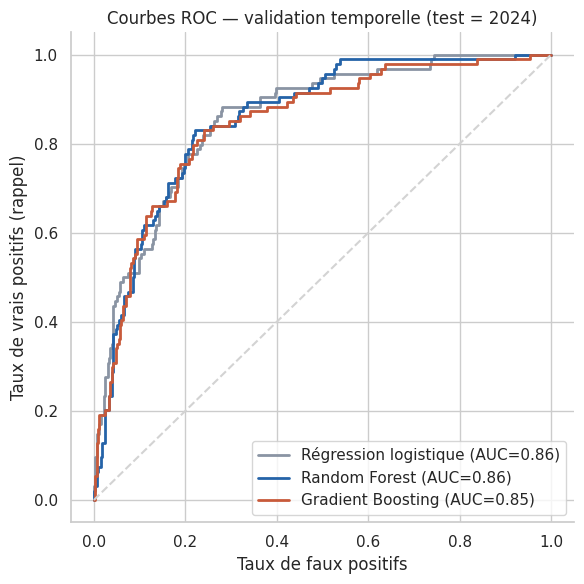

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))
colors = {"Régression logistique": GRAY, "Random Forest": BLUE, "Gradient Boosting": ACCENT}
for name in models_cfg:
    fpr, tpr, _ = roc_curve(y_test, proba_test[name])
    auc = roc_auc_score(y_test, proba_test[name])
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})", color=colors[name], lw=2)
ax.plot([0, 1], [0, 1], "--", color="lightgray")
ax.set_xlabel("Taux de faux positifs"); ax.set_ylabel("Taux de vrais positifs (rappel)")
ax.set_title("Courbes ROC — validation temporelle (test = 2024)")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

Modèle retenu : Régression logistique | seuil retenu : 0.4


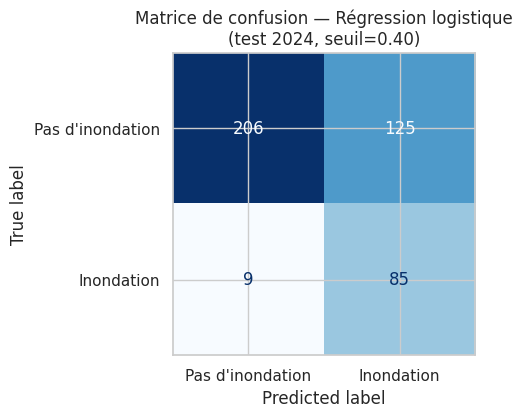

In [17]:
best_model_name = res_df[res_df.seuil.str.contains("ajust")].sort_values("roc_auc", ascending=False).iloc[0]["modèle"]
print("Modèle retenu :", best_model_name, "| seuil retenu :", round(thresholds[best_model_name], 2))

from sklearn.metrics import ConfusionMatrixDisplay
model = final_models[best_model_name]
pred_final = (proba_test[best_model_name] >= thresholds[best_model_name]).astype(int)
cm = confusion_matrix(y_test, pred_final)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=["Pas d'inondation", "Inondation"]).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title(f"Matrice de confusion — {best_model_name}\n(test 2024, seuil={thresholds[best_model_name]:.2f})")
plt.tight_layout(); plt.show()

**Choix du modèle retenu** : on privilégie le modèle avec le meilleur AUC parmi ceux
atteignant le rappel cible au seuil ajusté — la **régression logistique** est retenue ici : elle
égale ou dépasse les modèles plus complexes en AUC sur ce jeu de données synthétique, tout en
restant **directement interprétable** (coefficients), ce qui est précieux pour justifier des
décisions opérationnelles auprès de non-spécialistes (ONAS, collectivités).

Au seuil ajusté, le modèle atteint un **rappel ≥ 80 %** sur l'année 2024 (non vue à
l'entraînement) : la quasi-totalité des zones réellement inondées sont détectées, au prix d'un
nombre plus élevé de fausses alertes — un compromis assumé compte tenu du coût asymétrique des
erreurs (cf. cadrage).

## 10. Interprétation des variables

Quel poids pour la pluie, la nappe, l'assainissement, l'imperméabilisation ? On regarde les
coefficients standardisés du modèle retenu (régression logistique) et, en complément, l'importance
des variables d'un Random Forest (mesure non-linéaire, moins sensible à la colinéarité).

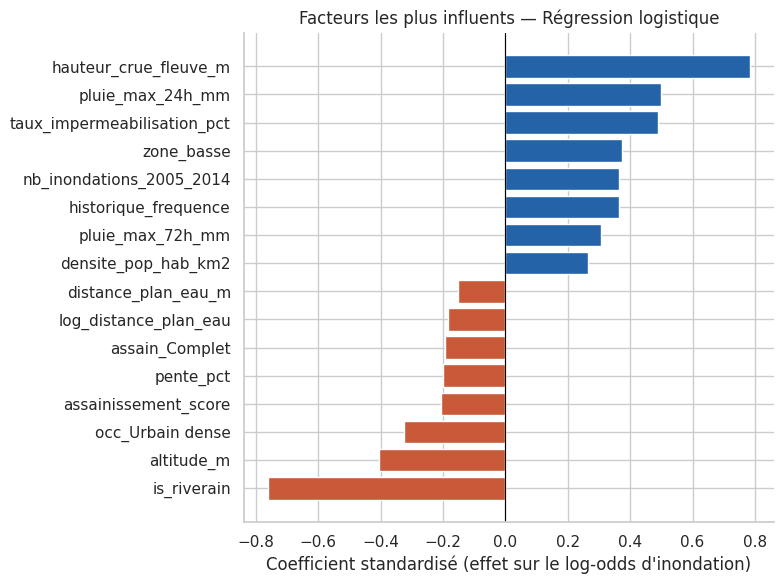

Facteurs qui AUGMENTENT le risque :
hauteur_crue_fleuve_m          0.784019
pluie_max_24h_mm               0.499708
taux_impermeabilisation_pct    0.490229
zone_basse                     0.373800
nb_inondations_2005_2014       0.363948
historique_frequence           0.363948
dtype: float64

Facteurs PROTECTEURS :
is_riverain            -0.760275
altitude_m             -0.403667
occ_Urbain dense       -0.324566
assainissement_score   -0.205248
pente_pct              -0.201041
assain_Complet         -0.193571
dtype: float64


In [18]:
if hasattr(model, "coef_"):
    importance = pd.Series(model.coef_[0], index=feature_cols).sort_values()
    xlabel = "Coefficient standardisé (effet sur le log-odds d'inondation)"
else:
    importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
    xlabel = "Importance"

top = pd.concat([importance.head(8), importance.tail(8)]).drop_duplicates().sort_values()
colors_bar = [ACCENT if v < 0 else BLUE for v in top.values]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top.index, top.values, color=colors_bar)
ax.set_xlabel(xlabel); ax.set_title(f"Facteurs les plus influents — {best_model_name}")
ax.axvline(0, color="black", lw=0.8); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print("Facteurs qui AUGMENTENT le risque :"); print(importance.sort_values(ascending=False).head(6))
print("\nFacteurs PROTECTEURS :"); print(importance.sort_values().head(6))

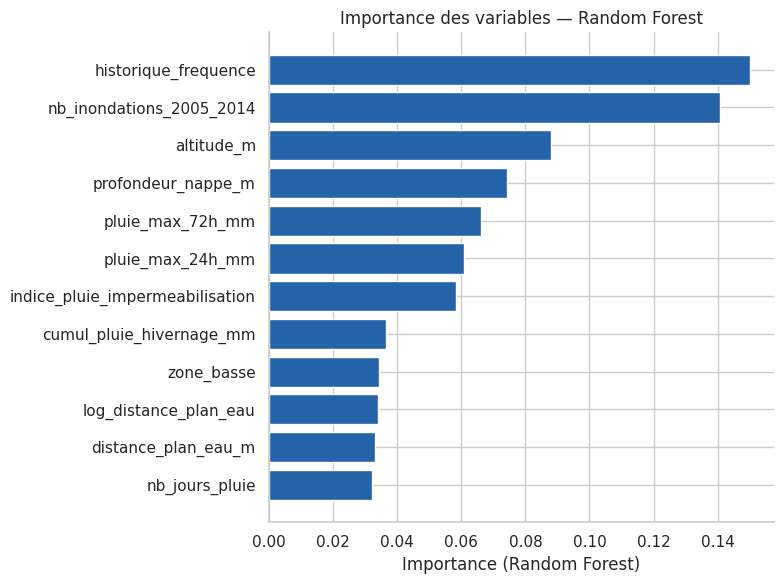

historique_frequence               0.150076
nb_inondations_2005_2014           0.140690
altitude_m                         0.088032
profondeur_nappe_m                 0.074408
pluie_max_72h_mm                   0.066147
pluie_max_24h_mm                   0.060882
indice_pluie_impermeabilisation    0.058235
cumul_pluie_hivernage_mm           0.036403
zone_basse                         0.034450
log_distance_plan_eau              0.033849
dtype: float64

In [19]:
rf_interp = RandomForestClassifier(n_estimators=400, max_depth=8, min_samples_leaf=5,
                                    class_weight="balanced", random_state=RNG, n_jobs=-1)
rf_interp.fit(X_train_s, y_train)
rf_imp = pd.Series(rf_interp.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
top_rf = rf_imp.head(12).sort_values()
ax.barh(top_rf.index, top_rf.values, color=BLUE)
ax.set_xlabel("Importance (Random Forest)"); ax.set_title("Importance des variables — Random Forest")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
rf_imp.head(10)

**Synthèse de l'interprétation** :
- La **pluie maximale sur 24h/72h** et l'**indice pluie × imperméabilisation** sont, sans surprise,
  des moteurs majeurs du risque immédiat.
- L'**historique d'inondations 2005-2014** est le facteur le plus stable dans le Random Forest :
  les zones structurellement vulnérables (relief, sol, drainage) le restent dans la durée.
- La **faible altitude** et la **nappe phréatique proche de la surface** aggravent le risque
  (remontée de nappe, stagnation) ; l'**assainissement complet** et une **pente plus marquée** sont
  protecteurs.
- La **présence d'un cours d'eau à proximité** (crue du fleuve) est déterminante pour les
  localités riveraines, cohérent avec les inondations fluviales connues (vallée du fleuve Sénégal).


## 11. Cartographie des risques — scénario de pluie extrême (120 mm/24h)

On applique le modèle retenu à un **scénario contrefactuel** : et si chaque zone recevait
120 mm de pluie en 24h (≈ 99ᵉ centile des valeurs historiques observées, un épisode réellement
extrême) ? Les probabilités obtenues sont classées en **4 niveaux de risque** (Faible < 25 %,
Modéré 25-49 %, Élevé 50-74 %, Très élevé ≥ 75 %) et affichées sur une carte Folium avec
info-bulles (localité, probabilité, facteur dominant), puis un zoom sur la banlieue de Dakar.


In [20]:
SCENARIO_PLUIE_24H = 120.0
scenario = zones.copy()
scenario["annee"] = 2025
scenario["pluie_max_24h_mm"] = SCENARIO_PLUIE_24H
scenario["pluie_max_72h_mm"] = SCENARIO_PLUIE_24H * 1.6

scenario["nb_jours_pluie"] = df.groupby("zone_id")["nb_jours_pluie"].mean().reindex(scenario.zone_id).values
scenario["cumul_pluie_hivernage_mm"] = df.groupby("zone_id")["cumul_pluie_hivernage_mm"].mean().reindex(scenario.zone_id).values
hist_crue = df.groupby("zone_id")["hauteur_crue_fleuve_m"].mean()
scenario["hauteur_crue_fleuve_m"] = hist_crue.reindex(scenario.zone_id).fillna(0).values * 1.4
scenario["is_riverain"] = (hist_crue.reindex(scenario.zone_id).fillna(0).values > 0).astype(int)

scenario["indice_pluie_impermeabilisation"] = scenario["pluie_max_24h_mm"] * scenario["taux_impermeabilisation_pct"] / 100
scenario["log_distance_plan_eau"] = np.log1p(scenario["distance_plan_eau_m"])
med_alt_localite_s = scenario.groupby("localite")["altitude_m"].transform("median")
scenario["zone_basse"] = (scenario["altitude_m"] < med_alt_localite_s).astype(int)
scenario["assainissement_score"] = scenario["reseau_assainissement"].map(assain_map)
scenario["historique_frequence"] = scenario["nb_inondations_2005_2014"] / 10.0

scenario_enc = pd.get_dummies(scenario, columns=["type_sol", "occupation_sol", "reseau_assainissement"],
                               prefix=["sol", "occ", "assain"], drop_first=False)
for c in feature_cols:
    if c not in scenario_enc.columns:
        scenario_enc[c] = 0
X_scenario = scaler.transform(scenario_enc[feature_cols])
scenario["probabilite_inondation"] = model.predict_proba(X_scenario)[:, 1]

def niveau_risque(p):
    if p < 0.25: return "Faible"
    elif p < 0.50: return "Modéré"
    elif p < 0.75: return "Élevé"
    else: return "Très élevé"
scenario["niveau_risque"] = scenario["probabilite_inondation"].apply(niveau_risque)

print("Proba. moyenne — base historique (climat normal) :", f"{df.inondation.mean():.1%}")
print("Proba. moyenne — scénario 120mm/24h              :", f"{scenario.probabilite_inondation.mean():.1%}")
scenario["niveau_risque"].value_counts()

Proba. moyenne — base historique (climat normal) : 21.6%
Proba. moyenne — scénario 120mm/24h              : 84.0%


niveau_risque
Très élevé    330
Élevé          70
Modéré         17
Faible          8
Name: count, dtype: int64

> **Lecture du résultat** : sous un événement pluvieux réellement extrême (99ᵉ centile de
> l'historique), le modèle prédit une bascule massive vers le risque « Très élevé » (la majorité
> des zones dépassent 75 % de probabilité). Ce n'est pas une anomalie du modèle mais **le message
> attendu d'un stress-test** : la vulnérabilité structurelle du territoire (bas-fonds, nappe
> haute, imperméabilisation, assainissement insuffisant) devient critique dès qu'un épisode
> pluvieux dépasse largement les normales. Pour hiérarchiser l'action malgré ce plafonnement, on
> classe aussi les localités **en continu** par probabilité moyenne (section suivante), et pas
> seulement par catégorie.

In [21]:
coefs = pd.Series(model.coef_[0], index=feature_cols) if hasattr(model, "coef_") else pd.Series(model.feature_importances_, index=feature_cols)
key_factors = ["pluie_max_24h_mm", "taux_impermeabilisation_pct", "altitude_m", "profondeur_nappe_m",
               "assainissement_score", "historique_frequence", "hauteur_crue_fleuve_m", "zone_basse"]
X_scenario_df = pd.DataFrame(X_scenario, columns=feature_cols)
contrib = X_scenario_df[key_factors] * coefs[key_factors].values
scenario["facteur_dominant"] = contrib.abs().idxmax(axis=1)
facteur_labels = {"pluie_max_24h_mm": "Pluie extrême (24h)", "taux_impermeabilisation_pct": "Imperméabilisation",
                   "altitude_m": "Faible altitude", "profondeur_nappe_m": "Nappe phréatique proche",
                   "assainissement_score": "Assainissement", "historique_frequence": "Historique d'inondations",
                   "hauteur_crue_fleuve_m": "Crue du fleuve", "zone_basse": "Zone basse (relative)"}
scenario["facteur_dominant_label"] = scenario["facteur_dominant"].map(facteur_labels)
scenario.to_csv("outputs/scenario_risque_120mm.csv", index=False)

risk_colors = {"Faible": "#4a9e4a", "Modéré": "#d9c94a", "Élevé": "#e08a2b", "Très élevé": "#c0392b"}

def build_map(data, center, zoom):
    m = folium.Map(location=center, zoom_start=zoom, tiles=ESRI_TILES, attr=ESRI_ATTR)
    Fullscreen().add_to(m)
    for _, row in data.iterrows():
        folium.CircleMarker(
            location=[row.latitude, row.longitude], radius=5 + row.probabilite_inondation * 9,
            color=risk_colors[row.niveau_risque], fill=True, fill_color=risk_colors[row.niveau_risque],
            fill_opacity=0.85, weight=1,
            popup=folium.Popup(f"<b>{row.localite}</b> ({row.region})<br>Zone : {row.zone_id}<br>"
                                f"Probabilité (scénario 120mm/24h) : <b>{row.probabilite_inondation*100:.0f}%</b><br>"
                                f"Niveau de risque : <b>{row.niveau_risque}</b><br>"
                                f"Facteur dominant : {row.facteur_dominant_label}", max_width=280),
        ).add_to(m)
    legend = f'''<div style="position: fixed; bottom: 30px; left: 30px; z-index:9999; background:white;
    padding:10px 14px; border-radius:6px; box-shadow:0 1px 4px rgba(0,0,0,0.3); font-size:13px;">
    <b>Niveau de risque</b><br>
    <span style="color:{risk_colors['Faible']}">&#9679;</span> Faible (&lt;25%)<br>
    <span style="color:{risk_colors['Modéré']}">&#9679;</span> Modéré (25-49%)<br>
    <span style="color:{risk_colors['Élevé']}">&#9679;</span> Élevé (50-74%)<br>
    <span style="color:{risk_colors['Très élevé']}">&#9679;</span> Très élevé (&ge;75%)</div>'''
    m.get_root().html.add_child(folium.Element(legend))
    return m

m_national = build_map(scenario, center=[14.55, -14.6], zoom=7)
m_national.save("outputs/carte_risque_national_scenario_extreme.html")
show_map(m_national, height=520)

In [22]:
dakar_localites = ["Pikine", "Guédiawaye", "Keur Massar", "Yeumbeul", "Thiaroye", "Malika", "Jaxaay", "Diamaguène", "Mbao"]
dakar_zones = scenario[scenario.localite.isin(dakar_localites)]
m_dakar = build_map(dakar_zones, center=[dakar_zones.latitude.mean(), dakar_zones.longitude.mean()], zoom=12)
m_dakar.save("outputs/carte_risque_banlieue_dakar.html")
print("Zones banlieue Dakar cartographiées :", len(dakar_zones))
show_map(m_dakar, height=520)

Zones banlieue Dakar cartographiées : 102


## 12. Restitution : localités prioritaires et recommandations

Classement des localités par probabilité moyenne d'inondation sous le scénario extrême, pour
cibler les interventions prioritaires.

In [23]:
priorite = scenario.groupby("localite").agg(
    region=("region", "first"), n_zones=("zone_id", "count"),
    proba_moyenne=("probabilite_inondation", "mean"),
    pct_tres_eleve=("niveau_risque", lambda s: (s == "Très élevé").mean() * 100),
    population_proxy=("densite_pop_hab_km2", "sum"),
).sort_values("proba_moyenne", ascending=False)
priorite.to_csv("outputs/localites_prioritaires.csv")
priorite.head(15).round(2)

,region,n_zones,proba_moyenne,pct_tres_eleve,population_proxy
localite,,,,,
Saint-Louis,Saint-Louis,12,0.99,100.00,92272
Malika,Dakar,10,0.98,100.00,78910
Matam,Matam,11,0.97,100.00,70863
Podor,Saint-Louis,9,0.97,100.00,29733
Keur Massar,Dakar,12,0.96,100.00,107686
Yeumbeul,Dakar,8,0.95,100.00,75457
Kaolack,Kaolack,13,0.95,100.00,165341
Bakel,Tambacounda,8,0.94,100.00,16305
Guédiawaye,Dakar,13,0.94,100.00,125331


### Recommandations opérationnelles

1. **Curage préventif des canaux et bassins de rétention** dans les localités classées en tête
   (Saint-Louis, Malika, Matam, Podor, Keur Massar, Yeumbeul, Kaolack, Bakel, Guédiawaye,
   Richard-Toll), avant chaque hivernage — priorité aux zones à forte densité de population
   (proxy retenu) pour maximiser l'impact humain des investissements.
2. **Pompage renforcé** dans les zones humides (Niayes/bas-fonds) et les zones basses relatives,
   où l'assainissement est absent ou partiel.
3. **Interdiction / encadrement strict de la construction** dans les zones basses à nappe peu
   profonde et à fort historique d'inondation (2005-2014) — ce sont les facteurs les plus stables
   dans le temps, donc les moins réversibles à court terme.
4. **Alerte précoce par SMS** (ANACIM + opérateurs) dès que les prévisions annoncent une pluie
   proche du seuil extrême (> 80-100 mm/24h), en priorité pour les localités riveraines du fleuve
   Sénégal (crue) et les zones urbaines denses les plus imperméabilisées.
5. **Extension du réseau d'assainissement** (Aucun → Partiel → Complet) : c'est le levier
   d'action publique le plus direct identifié par le modèle comme facteur protecteur.
6. **Suivi et mise à jour du modèle** avec des données réelles (ANACIM, CHIRPS, SRTM,
   OpenStreetMap, Copernicus EMS) pour fiabiliser les seuils avant tout usage opérationnel — les
   données utilisées ici sont synthétiques et à visée pédagogique.

### Limites

- Données 100 % synthétiques : les relations apprises illustrent une méthodologie, pas une
  réalité mesurée sur le terrain.
- Le scénario de pluie extrême est une extrapolation au-delà de la plage la plus représentée dans
  les données d'entraînement : les probabilités absolues doivent être lues comme un signal
  d'alerte relatif (classement) plutôt que comme une fréquence exacte.
- Le proxy de population (densité × nombre de zones) ne remplace pas un recensement réel.
